In [ ]:
import numpy as np
from PSO import *
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize

def simulate_voting_district(election1: np.ndarray, transfer_matrix: np.ndarray, precision = 500):
    """ Simulates election2 results given election1 and the transfer matrix, with some uncertaninty controlled by precision"""
    """ For a single voting district"""
    targets = np.dot(transfer_matrix, election1)
    return np.random.dirichlet(targets * precision)

def simulate_election_1(average_percents: np.ndarray, nb_districts = 100, precision = 100):
    """ Randomly draw election results in nb_districts districts"""
    """ For the moment for simplicity's sake all districts have the same size"""

    return np.random.dirichlet(average_percents * precision, size = nb_districts) 
    
def simulate_election_2_given_election_1(election1, transfer_matrix: np.ndarray, precision = 500):
    return np.array([simulate_voting_district(el1, transfer_matrix, precision=precision) for el1 in election1])
    # could be defined in more efficient way. for the moment it will serve the purpose

# first simulate elections

# first number: abstention. second round between first two candidates in first round (and abstention!)
# mat is a left-stochastic matrix
means1 = np.array([0.4, 0.3, 0.2, 0.1])
mat = np.array([[0.8, 0.03, 0.01, 0.5],[0.15, 0.95, 0.01, 0.3],[0.05, 0.02, 0.98, 0.2]])

ele_1 = simulate_election_1(means1, nb_districts=100, precision=50)
ele_2 = simulate_election_2_given_election_1(ele_1, mat, precision=100)

In [ ]:
# first simulate elections

# first number: abstention. second round between first two candidates in first round (and abstention!)
# mat is a left-stochastic matrix
means1 = np.array([0.4, 0.3, 0.2, 0.1])
mat = np.array([[0.8, 0.03, 0.01, 0.5],[0.15, 0.95, 0.01, 0.3],[0.05, 0.02, 0.98, 0.2]])

ele_1 = simulate_election_1(means1, nb_districts=100, precision=50)
ele_2 = simulate_election_2_given_election_1(ele_1, mat, precision=100)

"""
plt.hist(ele_1[:][0], bins=30, edgecolor='black')
plt.title("Histogram of the first component ele1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.hist(ele_2[:][0], bins=30, edgecolor='black')
plt.title("Histogram of the first component ele2")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()
"""

In [ ]:
print(mat)
# test particle swarm and genetic
print("Particle swarm", PSO_optimization(ele_1, ele_2, nb_particles = 64))
print("Genetic algorithm, last family", genetic_optimization(ele_1, ele_2, nb_particles = 16, nb_iterations=1000, sig = 0.8))

# these methods do not zwrk correctly. bad way of imposing the constraints? dimensionality curse?

[[0.8  0.03 0.01 0.5 ]
 [0.15 0.95 0.01 0.3 ]
 [0.05 0.02 0.98 0.2 ]]
9.581027251559517
Particle swarm [[0.47628559 0.39511833 0.26578486 0.08910642]
 [0.41181917 0.33430509 0.38548681 0.52440973]
 [0.11189524 0.27057658 0.34872833 0.38648386]]
Genetic algorithm [[[3.91078319e-01 2.74048272e-01 2.82938866e-01 4.07565341e-01]
  [2.52477371e-01 7.17421516e-01 1.69570097e-01 4.90701925e-01]
  [3.56444309e-01 8.53021278e-03 5.47491036e-01 1.01732734e-01]]

 [[5.30773778e-01 3.74341119e-01 1.28103594e-01 1.38368288e-01]
  [2.21998101e-01 4.16683189e-01 4.90375854e-01 4.63584737e-01]
  [2.47228121e-01 2.08975693e-01 3.81520551e-01 3.98046975e-01]]

 [[1.88489080e-01 6.65290336e-01 9.31592744e-02 3.05633141e-01]
  [5.82971493e-01 1.82530782e-01 5.47857979e-01 1.72474053e-01]
  [2.28539426e-01 1.52178882e-01 3.58982747e-01 5.21892806e-01]]

 [[2.96307940e-04 7.39336020e-01 5.60800232e-01 9.34596554e-02]
  [4.75330745e-01 2.53430602e-01 3.83060518e-01 2.43010090e-01]
  [5.24372947e-01 7.2333785

[0.45177037 0.50167274 0.31897062]
[0.3150546  0.26740944 0.12454468]
[0.4556564  0.39146376 0.38644707]
[0.32138866 0.334737   0.26954275]


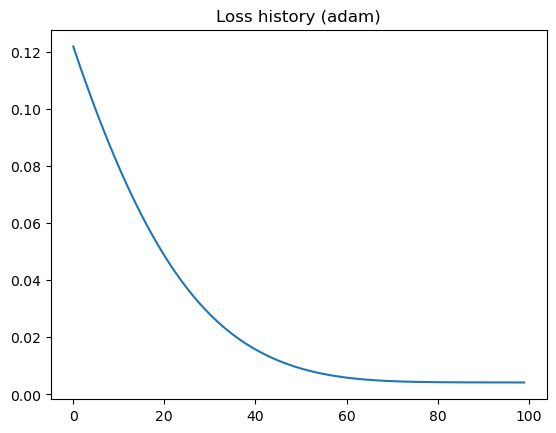

In [9]:
# ANOTHER APPROACH: try with a neural network using pytorch 
# dando percentuali al 100% per un candidato all'elezione 1 dovrebbe dare i trasferimenti di voti

# Convert lists to single tensors: (Batch, Height, Width)
X = torch.stack([torch.from_numpy(a) for a in ele_1]).float()
Y = torch.stack([torch.from_numpy(a) for a in ele_2]).float()

# Flatten the dimensions for a standard Linear layer
X_flat = X.view(X.size(0), -1)
Y_flat = Y.view(Y.size(0), -1)

# Define Model
model = nn.Sequential(
    nn.Linear(X_flat.size(1), 32),
    nn.ReLU(),
    nn.Linear(32, Y_flat.size(1))
)

# Training setup
# Adam: adaptive moment estimation. lr: initial step size
optimizer = optim.Adam(model.parameters(), lr=0.001)
# the model enters the optimizer by model.parameters()
criterion = nn.MSELoss() # use a mean squared error loss function
loss_history = []
# Simple Training Loop
for epoch in range(100):
    optimizer.zero_grad()
    prediction = model(X_flat)
    loss = criterion(prediction, Y_flat.float())
    loss.backward() # backpropagation
    optimizer.step() # parameter update, new_param = old_param - eta*gradient 
    # note that this works because prediction is a node in a dynamic computational graph
    # prediction thus carries a reference to grad_fn, which is passed over to loss via the criterion
    loss_history.append(loss.item())

# Now test what would happen with 100% for a condidate at a time
test_input = torch.tensor([[1,0,0,0]]).float()
predicted_flat = model(test_input)
predicted_array = predicted_flat.view(-1) # Reshape back to target dimensions
print(predicted_array.detach().numpy())

test_input = torch.tensor([[0,1,0,0]]).float()
predicted_flat = model(test_input)
predicted_array = predicted_flat.view(-1) # Reshape back to target dimensions
print(predicted_array.detach().numpy())

test_input = torch.tensor([[0,0,1,0]]).float()
predicted_flat = model(test_input)
predicted_array = predicted_flat.view(-1) # Reshape back to target dimensions
print(predicted_array.detach().numpy())

test_input = torch.tensor([[0,0,0,1]]).float()
predicted_flat = model(test_input)
predicted_array = predicted_flat.view(-1) # Reshape back to target dimensions
print(predicted_array.detach().numpy())

# does not work, even gives negatives results


plt.figure()
plt.plot(loss_history)
plt.title("Loss history (adam)")
plt.show()

# Gemini suggestion : have you considered a Softmax output layer with KLDivLoss (Kullback–Leibler divergence) instead of MSE

# TO DO: EXPLORE KL

# SEE KING'S ECOLOGICAL REGRESSION

In [18]:
# try linear regression with cosntraints using scipy.optimize.minimize
# ele_1 and ele_2 are defined in the first cell of this notebook

# extract dimensions
N = len(ele_2[0])
M = len(ele_1[0])

# transpose for a smarter way to compute the Frobenius norm
ele_1 = np.array(ele_1).T  
ele_2 = np.array(ele_2).T  

# first define the objective
def objective(m_flat):
    # Reshape flattened vector back to 3x4 matrix
    M = m_flat.reshape((N, M))
    # Use the Frobenius norm of (M.X - Y) as the loss to minimize
    return np.linalg.norm(M @ ele_1 - ele_2, 'fro')**2

# then define the constraints
cons = []
for j in range(M):
    # go through every colums
    def col_sum(m_flat, col_index=j):
        M = m_flat.reshape((N, M))
        return np.sum(M[:, col_index]) - 1 
    # col_sum has to be set to 0
    cons.append({'type': 'eq', 'fun': col_sum})
    # append a rule ('eq' means that col_sum has to be set to 0) for every column

# then impose that all entries of the transfer matrix be positive but not greater than 1
bounds = [(0, 1) for flat_matrix_index in range(N*M)]

# Use a simple uniform matrix starting point as initial guess
m0 = np.full((3, 4), 1/3).flatten()

# finally solve the problem using scipy.optimize's minimize tool
# using sequential lest squares
res = minimize(objective, m0, method='SLSQP', bounds=bounds, constraints=cons)
# reshape the result for clearer output
M_estimated = res.x.reshape((3, 4))

print("Estimated Matrix M:\n", M_estimated)
# check the constraint (left-stochastic matrix)
print("\nColumn Sums:", M_estimated.sum(axis=0))

ValueError: The number of bounds is not compatible with the length of `x0`.